In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Datasets


In [7]:
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

In [9]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [12]:
sentiment.shape
print("number of rows: ", sentiment.shape[0])
print("number of columns: ", sentiment.shape[1])

number of rows:  2644
number of columns:  4


In [13]:
trader.shape
print("number of rows: ", trader.shape[0])
print("number of columns: ", trader.shape[1])

number of rows:  211224
number of columns:  16


In [14]:
print(sentiment.columns)

print(trader.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Data Cleaning

In [36]:
print(sentiment.head())
print(sentiment.columns)

    timestamp  value classification       date        Date
0  1517463000     30           Fear 2018-02-01  2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02  2018-02-02
2  1517635800     40           Fear 2018-02-03  2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04  2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05  2018-02-05
Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='object')


In [15]:
sentiment.info()

trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [16]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum())

print()

print("Trader Missing Values")
print(trader.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [17]:
print("Sentiment Duplicate Rows:", sentiment.duplicated().sum())

print("Trader Duplicate Rows:", trader.duplicated().sum())

Sentiment Duplicate Rows: 0
Trader Duplicate Rows: 0


In [43]:
trader = trader.drop(columns=['Date'], errors='ignore')

In [46]:
print(trader[['Timestamp IST', 'Date']].head())

        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [48]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

## Merge Datasets

In [49]:
merged = pd.merge(
    trader,
    sentiment[['Date', 'value', 'classification']],
    on='Date',
    how='left'
)

In [50]:
print(merged[['Date', 'classification', 'value']].head(10))

print("Missing sentiment values:")
print(merged['classification'].isnull().sum())

         Date classification  value
0  2024-12-02  Extreme Greed   80.0
1  2024-12-02  Extreme Greed   80.0
2  2024-12-02  Extreme Greed   80.0
3  2024-12-02  Extreme Greed   80.0
4  2024-12-02  Extreme Greed   80.0
5  2024-12-02  Extreme Greed   80.0
6  2024-12-02  Extreme Greed   80.0
7  2024-12-02  Extreme Greed   80.0
8  2024-12-02  Extreme Greed   80.0
9  2024-12-02  Extreme Greed   80.0
Missing sentiment values:
6


In [51]:
print(trader['Date'].head())

print(sentiment['Date'].head())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: Date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object


In [52]:
sentiment[sentiment['Date'] == trader['Date'].iloc[0]]

,timestamp,value,classification,date,Date
2492,1733117400,80,Extreme Greed,2024-12-02,2024-12-02


In [53]:
trader['Date'].isin(sentiment['Date']).sum()

np.int64(211218)

In [54]:
len(trader)

211224

## Key Metrics
1. Daily PnL per Trader

In [56]:
daily_pnl = merged.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,Date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


2. Win Rate per Trader

In [57]:
merged['Win'] = merged['Closed PnL'] > 0

In [58]:
win_rate = (
    merged.groupby('Account')['Win']
    .mean()
    .mul(100)
    .reset_index(name='Win Rate (%)')
)

win_rate.head()

,Account,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


3.Average Trade Size

In [59]:
avg_trade_size = (
    merged.groupby('Account')['Size USD']
    .mean()
    .reset_index(name='Average Trade Size (USD)')
)

avg_trade_size.head()

,Account,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


4. Leverage Distribution
The provided dataset does not contain leverage information, so leverage distribution could not be analyzed.

5. Number of Trades per Day

In [61]:
trades_per_day = (
    merged.groupby('Date')
    .size()
    .reset_index(name='Number of Trades')
)

trades_per_day.head()

,Date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


6. Long vs Short Ratio

In [62]:
merged['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [63]:
long_short_ratio = (
    merged['Direction']
    .value_counts(normalize=True)
    .mul(100)
)

print(long_short_ratio)

Direction
Open Long                    23.621842
Close Long                   23.045677
Open Short                   18.814623
Close Short                  17.049672
Sell                          9.422225
Buy                           7.913873
Spot Dust Conversion          0.067227
Short > Long                  0.033140
Long > Short                  0.026986
Auto-Deleveraging             0.003787
Liquidated Isolated Short     0.000473
Settlement                    0.000473
Name: proportion, dtype: float64


In [64]:
daily_pnl.to_csv("daily_pnl.csv", index=False)
win_rate.to_csv("win_rate.csv", index=False)
avg_trade_size.to_csv("average_trade_size.csv", index=False)
trades_per_day.to_csv("trades_per_day.csv", index=False)

## Section B – Analysis

Question 1
Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

(A) Average PnL

In [82]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].agg(
    ['mean', 'median', 'sum', 'count']
)

print(pnl_sentiment)

                     mean  median           sum  count
classification                                        
Extreme Fear    34.537862     0.0  7.391102e+05  21400
Extreme Greed   67.892861     0.0  2.715171e+06  39992
Fear            54.290400     0.0  3.357155e+06  61837
Greed           42.743559     0.0  2.150129e+06  50303
Neutral         34.307718     0.0  1.292921e+06  37686


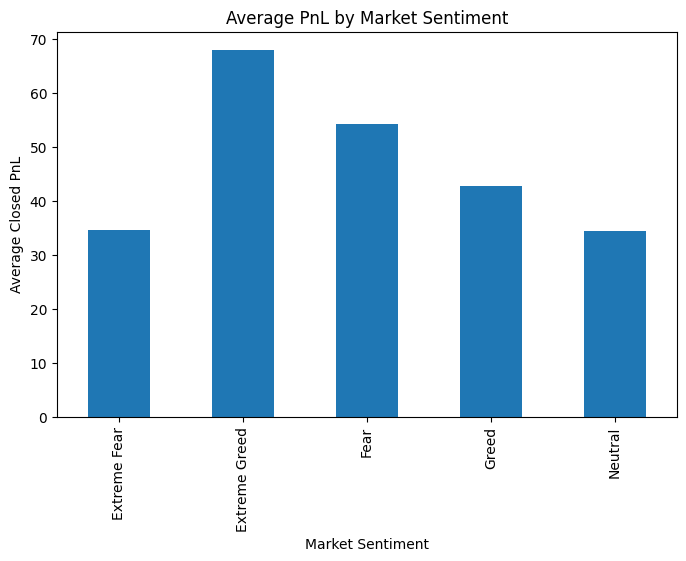

In [85]:
import matplotlib.pyplot as plt

avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

avg_pnl.plot(kind='bar', figsize=(8,5))

plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")

plt.show()

(B) Win Rate

In [66]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


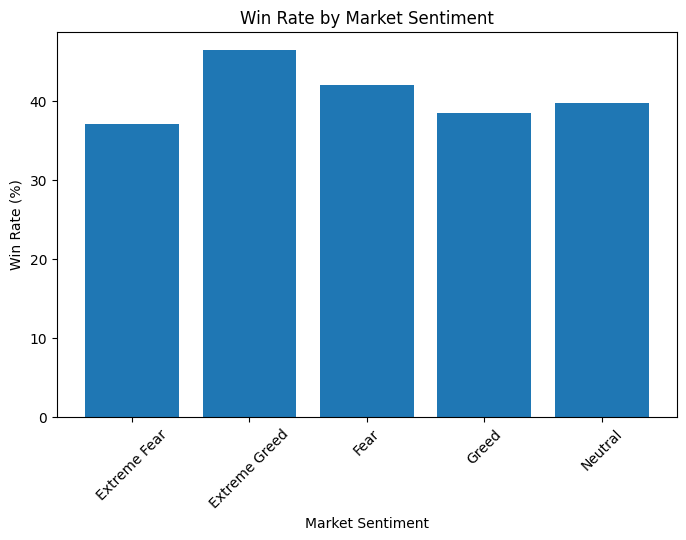

In [86]:
plt.figure(figsize=(8,5))
plt.bar(win_rate.index, win_rate.values)
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.show()

(C) Drawdown Proxy

In [67]:
drawdown = merged.groupby('classification')['Closed PnL'].min()

print(drawdown)

classification
Extreme Fear     -31036.69194
Extreme Greed    -10259.46800
Fear             -35681.74723
Greed           -117990.10410
Neutral          -24500.00000
Name: Closed PnL, dtype: float64


## Question 2
Do traders change behavior based on sentiment?

(A) Trade Frequency

In [69]:
trade_frequency = merged.groupby('classification').size()

print(trade_frequency)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


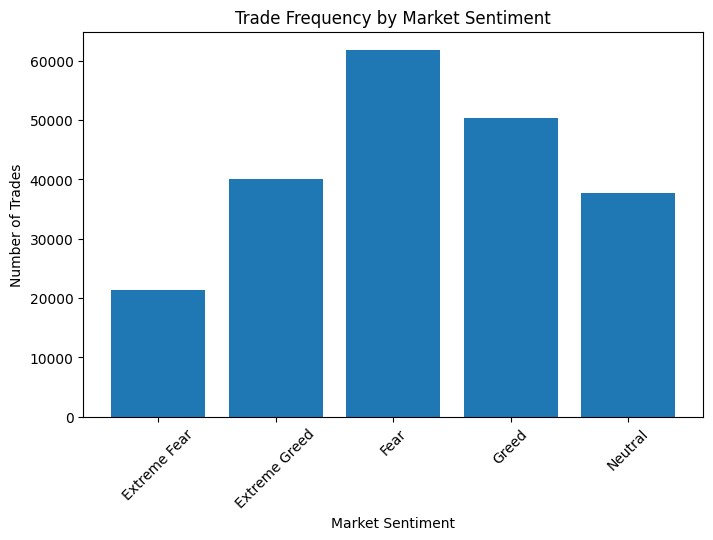

In [87]:
plt.figure(figsize=(8,5))
plt.bar(trade_frequency.index, trade_frequency.values)
plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

(B) Position Size

In [70]:
position_size = merged.groupby('classification')['Size USD'].mean()

print(position_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


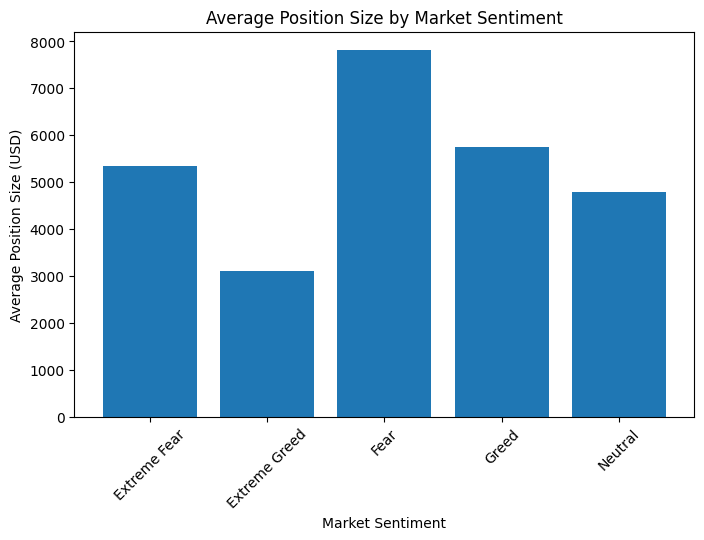

In [88]:
plt.figure(figsize=(8,5))
plt.bar(position_size.index, position_size.values)
plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")
plt.xticks(rotation=45)
plt.show()

(C) Long vs Short Bias

In [71]:
direction = pd.crosstab(
    merged['classification'],
    merged['Direction']
)

print(direction)

Direction       Auto-Deleveraging   Buy  Close Long  Close Short  \
classification                                                     
Extreme Fear                    0   807        6241         3117   
Extreme Greed                   0  5132        7186         6497   
Fear                            0  3207       17260         9221   
Greed                           8  4685        7998        11322   
Neutral                         0  2885        9993         5850   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                            0             5       7005   
Extreme Greed                           0             7       6300   
Fear                                    0            14      17824   
Greed                                   1            16       8544   
Neutral                                 0            15      10222   

Direction       Open Short  Sell

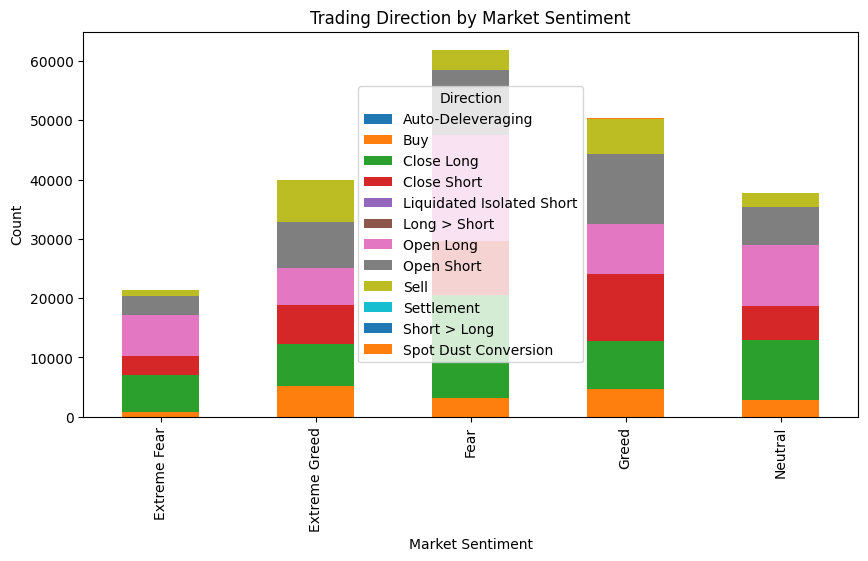

In [89]:
direction.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Trading Direction by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Count")
plt.show()

## Question 3

Segment 1

## Frequent vs Infrequent Traders

Calculate trades per account.

In [72]:
trade_count = merged.groupby('Account').size()

median_trade = trade_count.median()

segments = trade_count.apply(
    lambda x: 'Frequent Trader'
    if x >= median_trade
    else 'Infrequent Trader'
)

segments = segments.reset_index()

segments.columns = ['Account','Segment']

In [91]:
trade_count = merged.groupby('Account').size()

median_trade = trade_count.median()

segments = trade_count.apply(
    lambda x: 'Frequent Trader' if x >= median_trade else 'Infrequent Trader'
)

merged['Segment'] = merged['Account'].map(segments)

In [92]:
segment_pnl = merged.groupby('Segment')['Closed PnL'].mean()

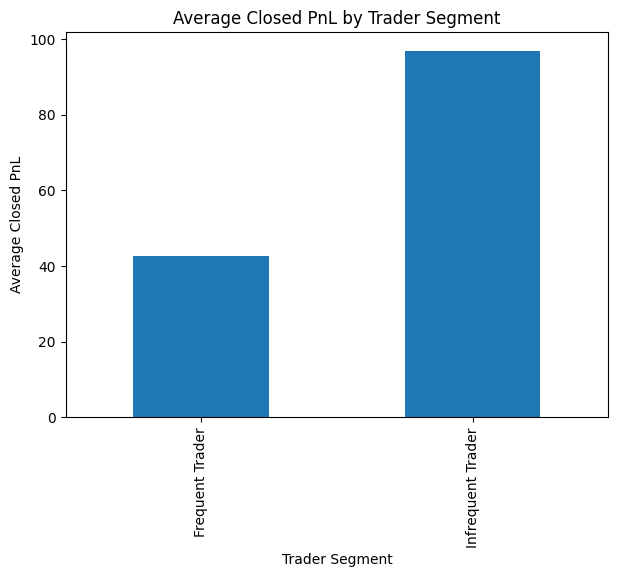

In [93]:
segment_pnl.plot(kind='bar', figsize=(7,5))
plt.title("Average Closed PnL by Trader Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average Closed PnL")
plt.show()

In [73]:
merged = merged.merge(
    segments,
    on='Account'
)

In [74]:
merged.groupby('Segment')['Closed PnL'].mean()

Segment
Frequent Trader      42.493421
Infrequent Trader    96.943024
Name: Closed PnL, dtype: float64

Segment 2
## Consistent Winners vs Inconsistent Traders

In [75]:
win_rate_account = merged.groupby('Account')['Win'].mean()

In [76]:
winner_segment = win_rate_account.apply(
    lambda x: 'Consistent Winner'
    if x >= 0.60
    else 'Inconsistent Trader'
)

winner_segment = winner_segment.reset_index()

winner_segment.columns = ['Account','Winner Segment']

In [77]:
merged = merged.merge(
    winner_segment,
    on='Account'
)

In [78]:
merged.groupby('Winner Segment')['Closed PnL'].mean()

Winner Segment
Consistent Winner      38.319560
Inconsistent Trader    49.261483
Name: Closed PnL, dtype: float64

Segment 3
## Large Position vs Small Position




In [79]:
median_size = merged['Size USD'].median()

merged['Position Segment'] = merged['Size USD'].apply(
    lambda x: 'Large Position'
    if x >= median_size
    else 'Small Position'
)

In [80]:
merged.groupby('Position Segment')['Closed PnL'].mean()

Position Segment
Large Position    93.116556
Small Position     4.381445
Name: Closed PnL, dtype: float64

# Question 3: Trader Segmentation Analysis

## Frequent vs Infrequent Traders

Frequent traders recorded an average Closed PnL of **42.49**, whereas Infrequent traders recorded **96.94**. This suggests that executing a higher number of trades does not necessarily lead to higher profitability.

## Consistent Winners vs Inconsistent Traders

Consistent Winners recorded an average Closed PnL of **38.32**, while Inconsistent Traders recorded **49.26**. This indicates that a higher win rate alone does not always result in the highest average profit, as trade size and profit per trade also influence overall performance.

## Large Position vs Small Position Traders

Large Position traders achieved significantly higher average profits (**93.12**) compared to Small Position traders (**4.38**), indicating that position size has a strong impact on profitability.



# Question 4: Insights from Analysis

## Insight 1: Trading performance improves during Extreme Greed.

The analysis shows that **Extreme Greed** recorded the highest average Closed PnL (**67.89**) and the highest win rate (**46.49%**). In comparison, **Extreme Fear** recorded a lower average Closed PnL (**34.54**) and the lowest win rate (**37.06%**). This indicates that traders generally perform better during positive market sentiment.

**Evidence:** Average PnL table and Win Rate chart.

---

## Insight 2: Traders are more active during Fear market conditions.

The trade frequency analysis shows that **Fear** had the highest number of trades (**61,837**), followed by **Greed (50,303)**. This suggests that traders tend to trade more frequently during uncertain or volatile market conditions.

**Evidence:** Trade Frequency table/bar chart.

---

## Insight 3: Larger position sizes are associated with higher profitability.

The segmentation analysis shows that **Large Position** traders achieved an average Closed PnL of approximately **93.12**, while **Small Position** traders achieved only **4.38**. This indicates that larger position sizes generated higher profits, although they may also involve higher risk.

**Evidence:** Position Size analysis and trader segmentation table.



# Part C – Summary

## Methodology

This project analyzes the relationship between cryptocurrency market sentiment and trader behavior using the Fear & Greed Index and historical trading data.

The analysis was performed using the following steps:

- Loaded the historical trader dataset and Fear & Greed Index dataset.
- Checked and cleaned the datasets by identifying missing and duplicate values.
- Converted timestamp columns into datetime format.
- Merged both datasets using the common **Date** column.
- Calculated performance metrics such as Closed PnL, Win Rate, Trade Frequency, Position Size, and Drawdown Proxy.
- Compared trader performance across different market sentiment categories.
- Segmented traders into:
  - Frequent vs Infrequent Traders
  - Consistent Winners vs Inconsistent Traders
  - Large Position vs Small Position Traders

---

# Key Insights

### Insight 1: Market sentiment influences trading performance.

The highest win rate was observed during **Extreme Greed (46.49%)**, while **Extreme Fear (37.06%)** recorded the lowest win rate. This indicates that traders generally perform better during optimistic market conditions.

### Insight 2: Trading activity increases during Fear markets.

The highest number of trades occurred during **Fear (61,837 trades)**, followed by **Greed (50,303 trades)**. This suggests that traders become more active during volatile or uncertain market conditions.

### Insight 3: Position size affects profitability.

Large Position traders achieved a significantly higher average Closed PnL than Small Position traders, indicating that larger trades generate higher returns but may also involve greater risk.

---

# Strategy Recommendations

### Recommendation 1

Use market sentiment as an additional trading signal. During **Extreme Greed**, traders achieved higher win rates, whereas **Fear** periods showed lower performance and higher downside risk.

### Recommendation 2

Apply stronger risk management during Fear and Extreme Fear markets by reducing position sizes and using stop-loss strategies to minimize potential losses.